In [29]:
# === 1. LOAD & INSPECT ===
import pandas as pd
import numpy as np

# ---- config ----
DATA_PATH = "C:/Users/User/OneDrive - University of Exeter/Desktop/Business Project/olist_customer_segmentation_dataset3_with_comments.csv"

# Load
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

# Basic type info
print("\nInfo:")
print(df.info())

# Quick peek
display(df.head(10))

# Numeric & categorical separation
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nNumeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# Descriptive stats
print("\nDescriptive statistics (numeric):")
display(df[num_cols].describe().T)

# Missing values (count & %)
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing.sort_values("missing_count", ascending=False))


Shape: (93358, 12)

Columns: ['customer_unique_id', 'total_orders', 'total_spend', 'avg_order_value', 'avg_payment_installments', 'avg_review_score', 'category_diversity', 'recency_days', 'most_common_category', 'customer_city', 'customer_state', 'review_comment_message']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_unique_id        93358 non-null  object 
 1   total_orders              93358 non-null  int64  
 2   total_spend               93358 non-null  float64
 3   avg_order_value           93357 non-null  float64
 4   avg_payment_installments  93357 non-null  float64
 5   avg_review_score          92755 non-null  float64
 6   category_diversity        93358 non-null  int64  
 7   recency_days              93358 non-null  int64  
 8   most_common_category      92079 non-null  object 
 9   c

,customer_unique_id,total_orders,total_spend,avg_order_value,avg_payment_installments,avg_review_score,category_diversity,recency_days,most_common_category,customer_city,customer_state,review_comment_message
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,8.0,5.0,1,111,bed_bath_table,cajamar,SP,"Adorei a cortina, ficou linda na minha sala, e..."
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1.0,4.0,1,114,health_beauty,osasco,SP,NaN
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,8.0,3.0,1,536,stationery,sao jose,SC,NaN
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,4.0,1,320,telephony,belem,PA,Bom vendedor
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,6.0,5.0,1,287,telephony,sorocaba,SP,NaN
5,0004bd2a26a76fe21f786e4fbd80607f,1,166.98,166.98,8.0,4.0,1,145,garden_tools,sao paulo,SP,NaN
6,00050ab1314c0e55a6ca13cf7181fecf,1,35.38,35.38,1.0,4.0,1,131,telephony,campinas,SP,NaN
7,00053a61a98854899e70ed204dd4bafe,1,838.36,419.18,3.0,1.0,1,182,sports_leisure,curitiba,PR,Olá! Comprei dois potes de whey e chegou apena...
8,0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,3.0,4.0,1,542,fashion_bags_accessories,teresopolis,RJ,NaN
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,129.76,129.76,4.0,1.0,1,169,sports_leisure,sao luis,MA,Até o presente momento não recebi o produto e ...



Numeric columns: ['total_orders', 'total_spend', 'avg_order_value', 'avg_payment_installments', 'avg_review_score', 'category_diversity', 'recency_days']
Categorical columns: ['customer_unique_id', 'most_common_category', 'customer_city', 'customer_state', 'review_comment_message']

Descriptive statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
total_orders,93358.0,1.033420,0.209097,1.000000,1.00,1.00,1.0000,15.00
total_spend,93358.0,212.964557,646.223866,0.000000,63.83,113.14,202.6375,109312.64
avg_order_value,93357.0,157.787462,217.029531,1.856818,60.73,103.59,174.7300,13664.08
avg_payment_installments,93357.0,2.900294,2.677079,0.000000,1.00,2.00,4.0000,24.00
avg_review_score,92755.0,4.153363,1.280573,1.000000,4.00,5.00,5.0000,5.00
category_diversity,93358.0,1.010979,0.204645,0.000000,1.00,1.00,1.0000,5.00
recency_days,93358.0,236.941773,152.591453,0.000000,113.00,218.00,345.0000,713.00


,missing_count,missing_pct
review_comment_message,55334,59.27
most_common_category,1279,1.37
avg_review_score,603,0.65
avg_order_value,1,0.00
avg_payment_installments,1,0.00
customer_unique_id,0,0.00
total_orders,0,0.00
total_spend,0,0.00
category_diversity,0,0.00
recency_days,0,0.00


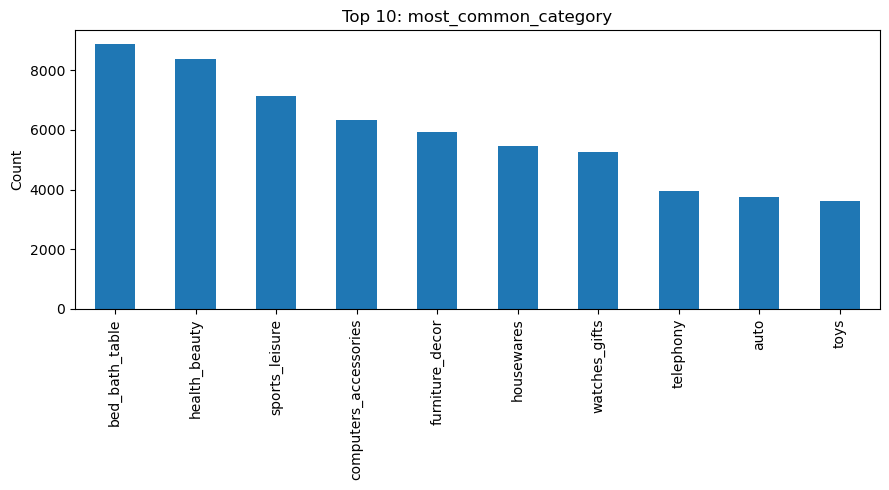

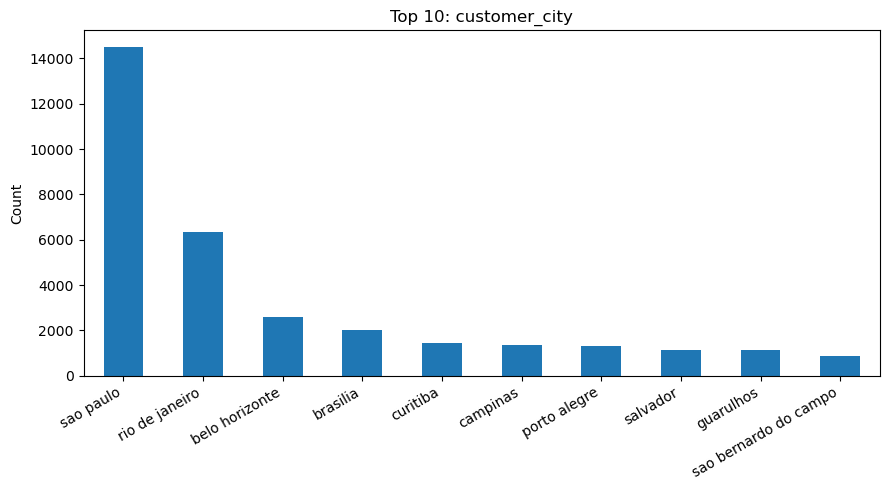

In [31]:
# === 2. TOP-10 CATEGORY & CITY ===
import matplotlib.pyplot as plt

def plot_top_k_bar(series, title, k=10, rotation=0):
    counts = series.dropna().value_counts().head(k)
    plt.figure(figsize=(9,5))
    counts.plot(kind="bar")
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Count")
    if rotation:
        plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()

# Column name robustness
def pick_col(candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

col_category = pick_col(["most_common_category", "top_category", "primary_category"])
col_city     = pick_col(["most_common_city", "customer_city", "top_city"])

if col_category:
    plot_top_k_bar(df[col_category], f"Top 10: {col_category}")
else:
    print("Column for 'most_common_category' not found.")

if col_city:
    # Rotate labels a bit for city names
    plot_top_k_bar(df[col_city], f"Top 10: {col_city}", rotation=30)
else:
    print("Column for 'most_common_city' not found.")


Metrics found: {'total_orders': 'total_orders', 'total_spend': 'total_spend', 'avg_order_value': 'avg_order_value', 'avg_payment_installments': 'avg_payment_installments', 'avg_review_score': 'avg_review_score', 'category_diversity': 'category_diversity', 'recency_days': 'recency_days'}


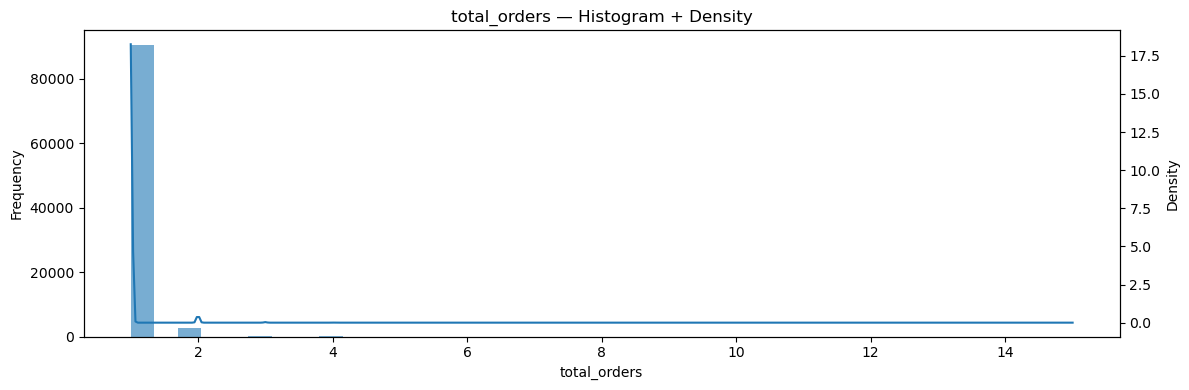

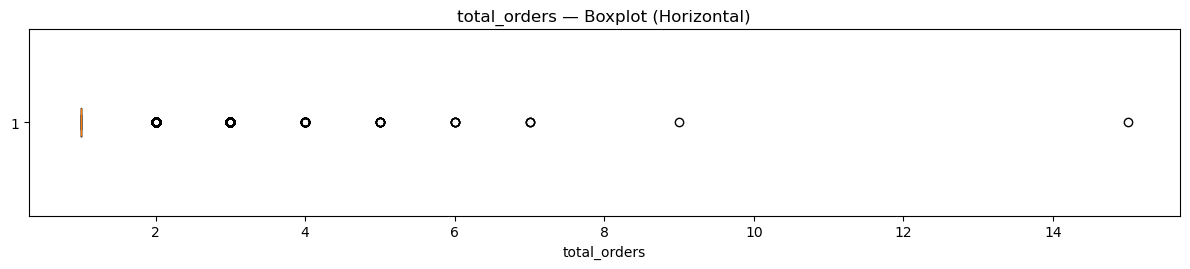

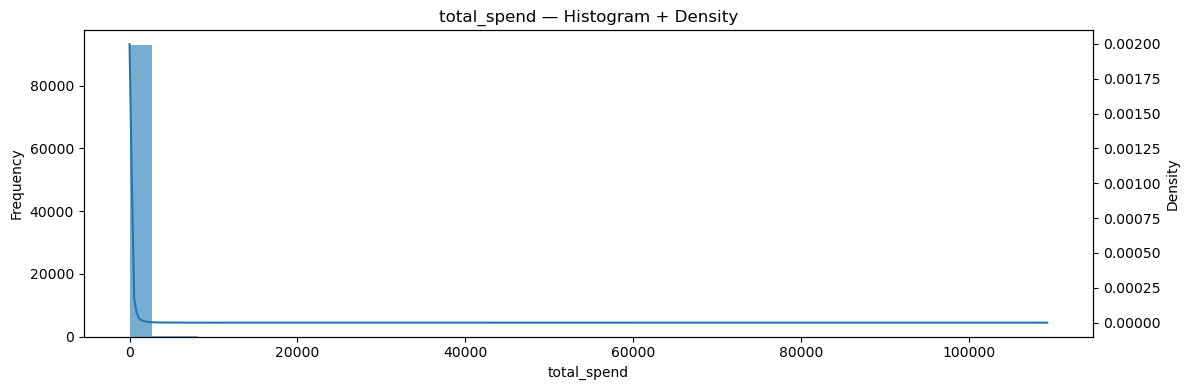

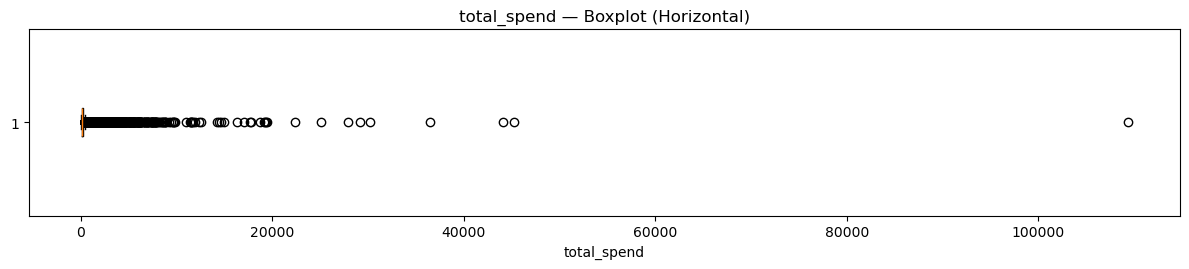

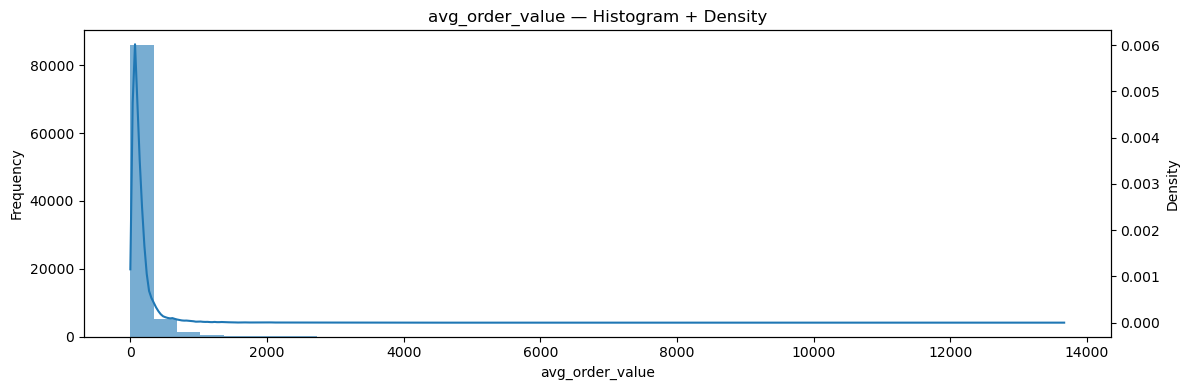

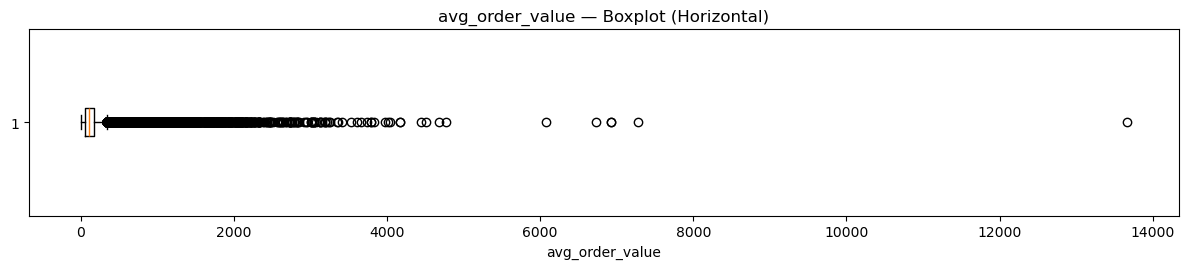

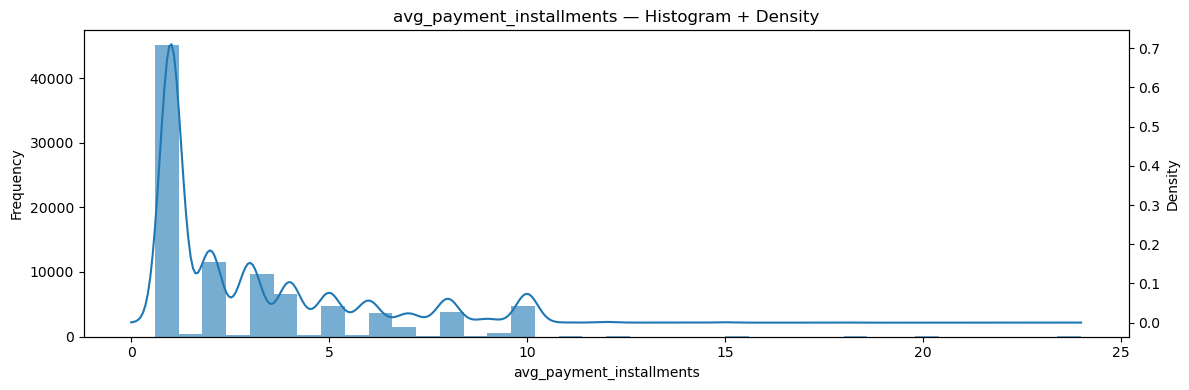

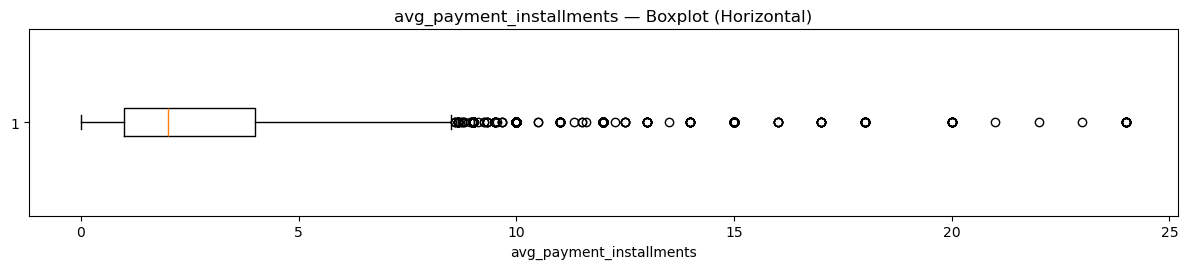

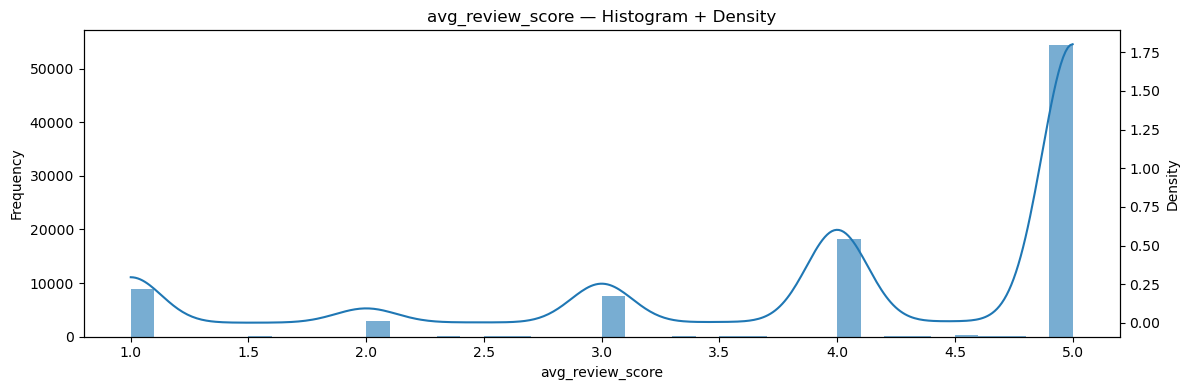

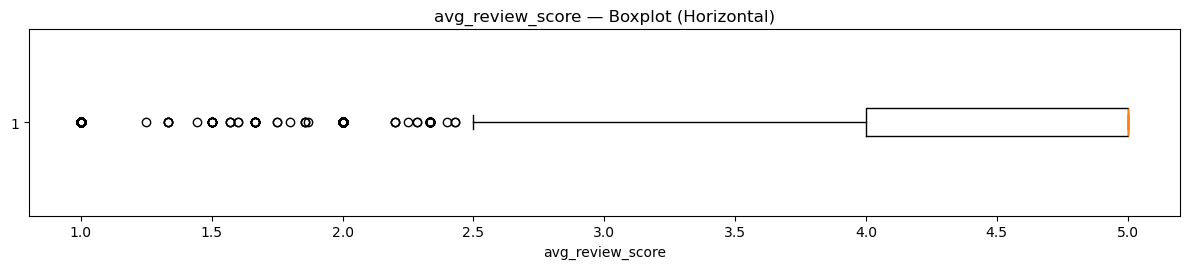

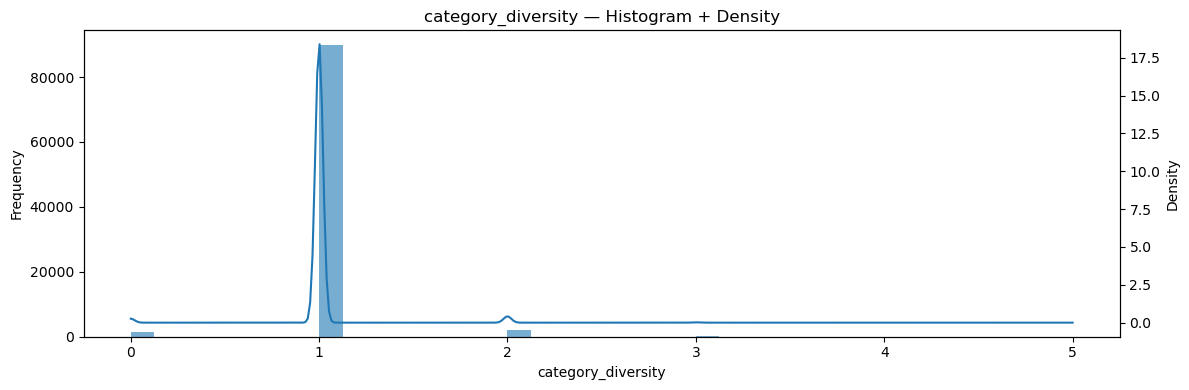

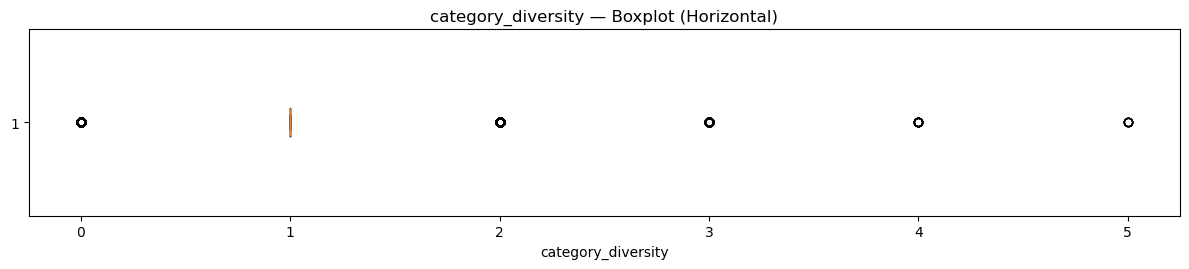

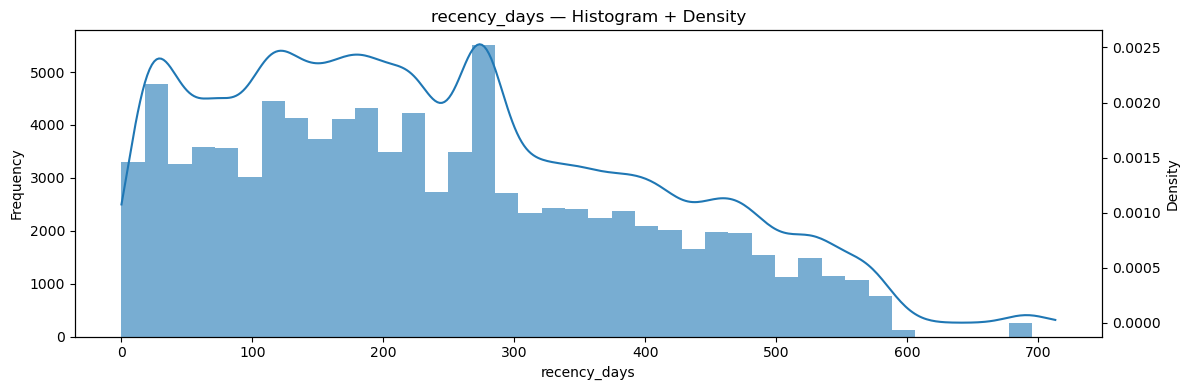

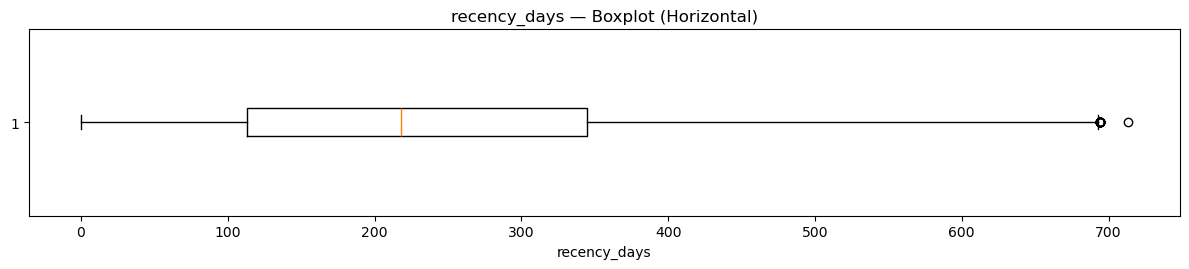

In [33]:
# === 3. DISTRIBUTIONS + OUTLIERS (hist + density + horizontal box) ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde  # for smooth density curve

def get_metric_col(possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    return None

metrics_map = {
    "total_orders": get_metric_col(["total_orders", "total_order"]),
    "total_spend": get_metric_col(["total_spend", "total_payment", "sum_payment_value"]),
    "avg_order_value": get_metric_col(["avg_order_value", "aov"]),
    "avg_payment_installments": get_metric_col(["avg_payment_installments", "avg_installments"]),
    "avg_review_score": get_metric_col(["avg_review_score", "mean_review_score"]),
    "category_diversity": get_metric_col(["category_diversity", "unique_categories"]),
    "recency_days": get_metric_col(["recency_days", "recency"])
}

metrics = [v for v in metrics_map.values() if v is not None]
print("Metrics found:", metrics_map)

def plot_hist_density_box(series, name, bins=40):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        print(f"[WARN] {name} has no non-NA values.")
        return
    
    # Histogram + density (secondary y-axis)
    fig, ax1 = plt.subplots(figsize=(12,4))
    counts, bin_edges, _ = ax1.hist(s, bins=bins, alpha=0.6)
    ax1.set_title(f"{name} — Histogram + Density")
    ax1.set_xlabel(name)
    ax1.set_ylabel("Frequency")

    # Smooth density curve
    try:
        kde = gaussian_kde(s)
        xs = np.linspace(s.min(), s.max(), 400)
        density = kde(xs)
        ax2 = ax1.twinx()
        ax2.plot(xs, density)
        ax2.set_ylabel("Density")
    except Exception as e:
        print(f"[INFO] KDE skipped for {name}: {e}")

    plt.tight_layout()
    plt.show()

    # Horizontal boxplot
    plt.figure(figsize=(12,2.8))
    plt.boxplot(s, vert=False, showfliers=True)
    plt.title(f"{name} — Boxplot (Horizontal)")
    plt.xlabel(name)
    plt.tight_layout()
    plt.show()

for m in metrics:
    plot_hist_density_box(df[m], m)


Metrics found: {'total_orders': 'total_orders', 'total_spend': 'total_spend', 'avg_order_value': 'avg_order_value', 'avg_payment_installments': 'avg_payment_installments', 'avg_review_score': 'avg_review_score', 'category_diversity': 'category_diversity', 'recency_days': 'recency_days'}


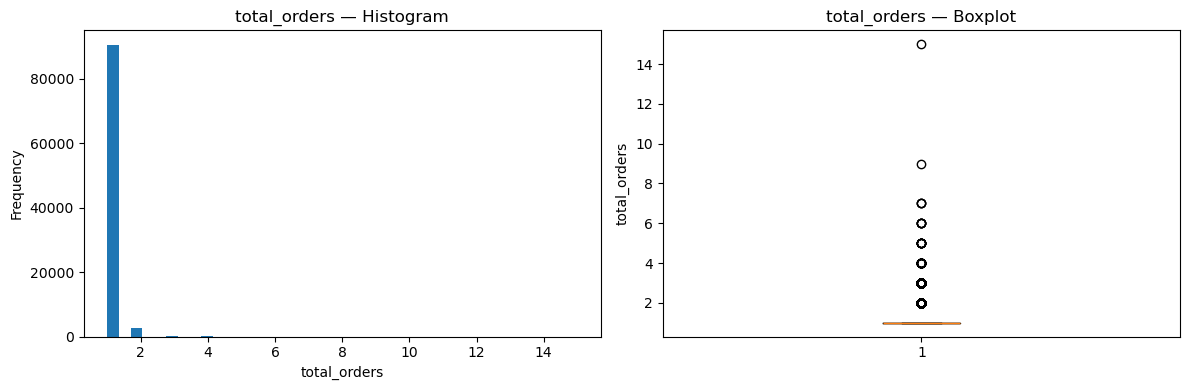

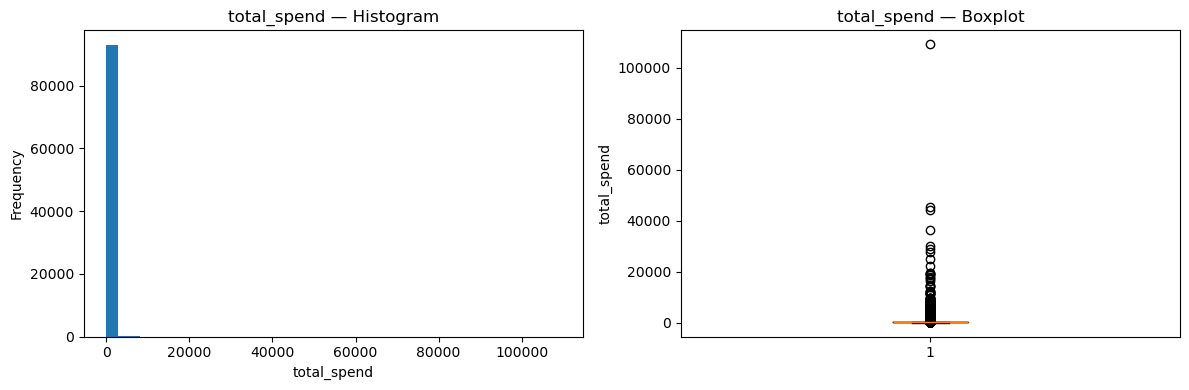

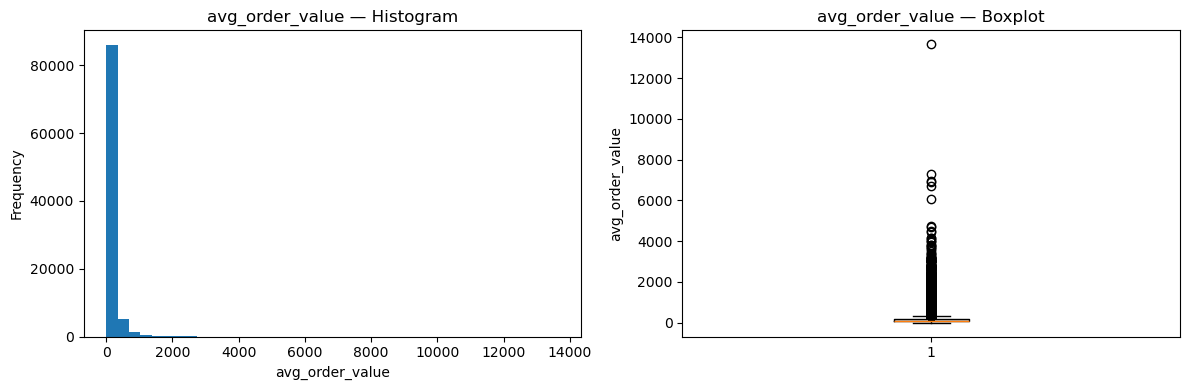

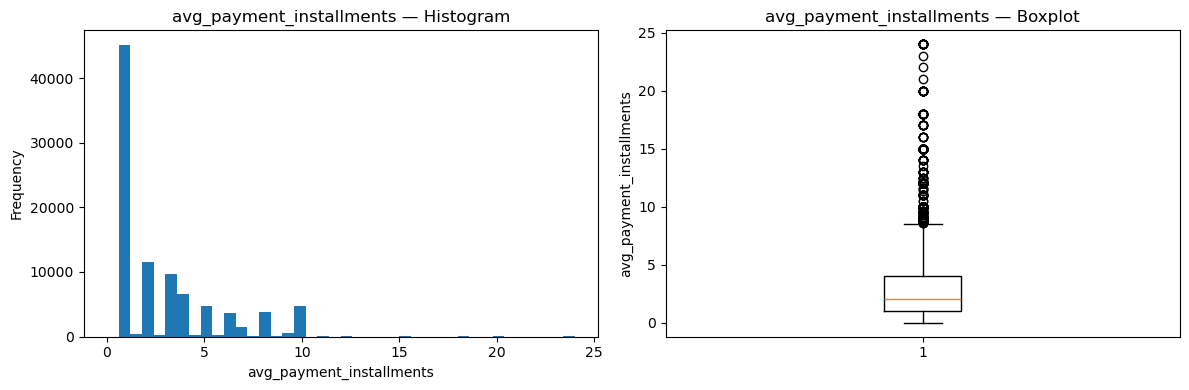

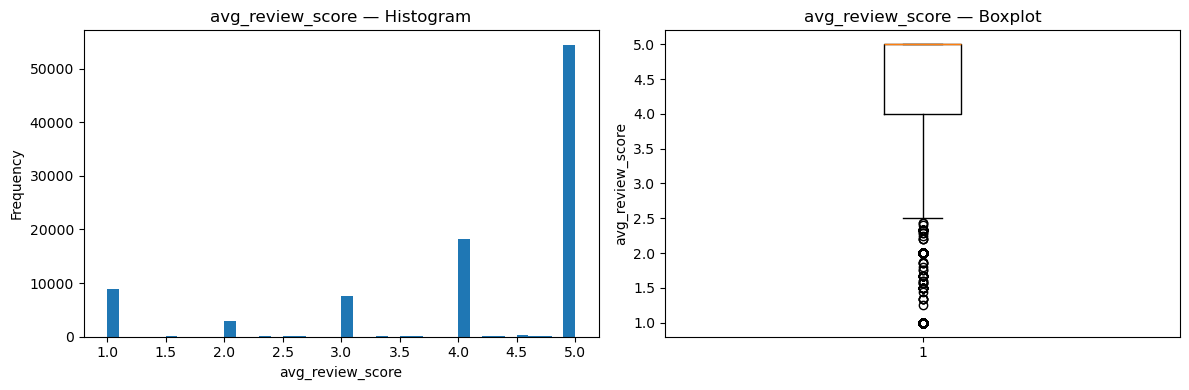

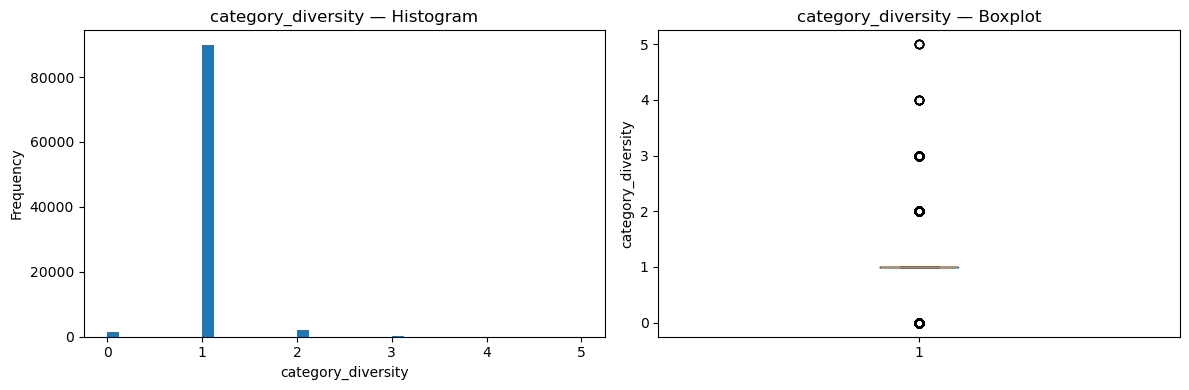

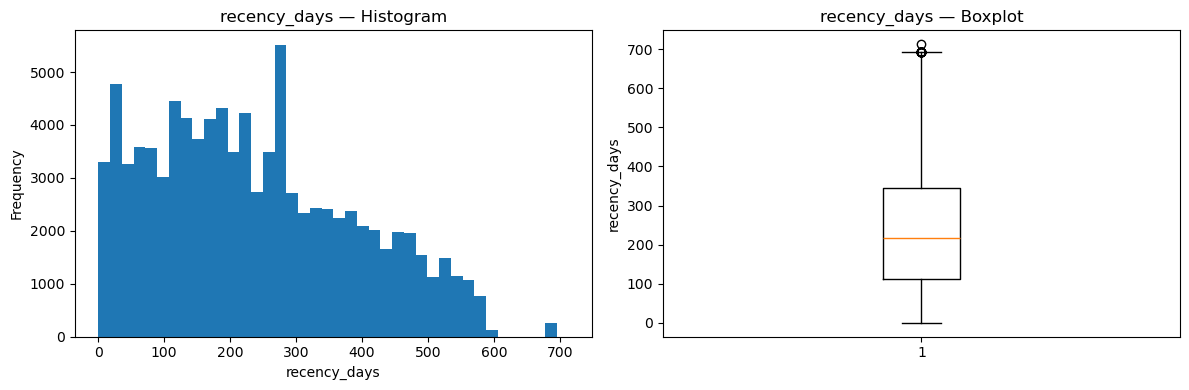

In [35]:
# === 3. DISTRIBUTIONS + OUTLIERS ===
import matplotlib.pyplot as plt

# Robust column picking (supports singular/plural & common variants)
def get_metric_col(possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    return None

metrics_map = {
    "total_orders": get_metric_col(["total_orders", "total_order"]),
    "total_spend": get_metric_col(["total_spend", "total_payment", "sum_payment_value"]),
    "avg_order_value": get_metric_col(["avg_order_value", "aov"]),
    "avg_payment_installments": get_metric_col(["avg_payment_installments", "avg_installments"]),
    "avg_review_score": get_metric_col(["avg_review_score", "mean_review_score"]),
    "category_diversity": get_metric_col(["category_diversity", "unique_categories"]),
    "recency_days": get_metric_col(["recency_days", "recency"])
}

metrics = [v for v in metrics_map.values() if v is not None]
print("Metrics found:", metrics_map)

def plot_hist_box(series, name, bins=40):
    s = series.dropna()
    if s.empty:
        print(f"[WARN] {name} has no non-NA values.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].hist(s, bins=bins)
    axes[0].set_title(f"{name} — Histogram")
    axes[0].set_xlabel(name)
    axes[0].set_ylabel("Frequency")

    axes[1].boxplot(s, vert=True, showfliers=True)
    axes[1].set_title(f"{name} — Boxplot")
    axes[1].set_ylabel(name)

    plt.tight_layout()
    plt.show()

for m in metrics:
    plot_hist_box(df[m], m)


In [37]:
# === 4. IMPUTATION (median numeric, mode categorical) ===

df_clean = df.copy()

# Numeric: median
for c in df_clean.select_dtypes(include=[np.number]).columns:
    med = df_clean[c].median()
    df_clean[c] = df_clean[c].fillna(med)

# Categorical: mode (first if multiple)
for c in df_clean.select_dtypes(exclude=[np.number]).columns:
    if df_clean[c].isna().any():
        mode_vals = df_clean[c].mode(dropna=True)
        if not mode_vals.empty:
            df_clean[c] = df_clean[c].fillna(mode_vals.iloc[0])

print("Imputation complete.")
# Quick check
display(df_clean.isna().sum().sort_values(ascending=False).to_frame("missing_after_impute").head(15))


Imputation complete.


,missing_after_impute
customer_unique_id,0
total_orders,0
total_spend,0
avg_order_value,0
avg_payment_installments,0
avg_review_score,0
category_diversity,0
recency_days,0
most_common_category,0
customer_city,0


In [39]:
# === 5. WINSORIZATION (IQR) — add *_winsor columns into the working dataset ===
def winsorize_iqr(s: pd.Series) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    return x.clip(lower=lb, upper=ub)

# Ensure we’re working on the already-imputed data
if 'df_clean' not in globals():
    df_clean = df.copy()

col_total_orders     = metrics_map.get("total_orders")
col_total_spend      = metrics_map.get("total_spend")
col_avg_order_value  = metrics_map.get("avg_order_value")

to_winsorize = {
    "total_orders_winsor": col_total_orders,
    "total_spend_winsor": col_total_spend,
    "avg_order_value_winsor": col_avg_order_value
}

missing_any = [new for new, base in to_winsorize.items() if base is None]
if missing_any:
    print("These winsorized targets are missing base columns:", missing_any)

# Add *_winsor columns **into df_clean directly**
for new_col, base_col in to_winsorize.items():
    if base_col is not None:
        df_clean[new_col] = winsorize_iqr(df_clean[base_col])
        print(f"Added column: {new_col} (from {base_col})")

# Keep a final reference dataset with originals + winsorized
df_final = df_clean.copy()
display(df_final.head())


Added column: total_orders_winsor (from total_orders)
Added column: total_spend_winsor (from total_spend)
Added column: avg_order_value_winsor (from avg_order_value)


,customer_unique_id,total_orders,total_spend,avg_order_value,avg_payment_installments,avg_review_score,category_diversity,recency_days,most_common_category,customer_city,customer_state,review_comment_message,total_orders_winsor,total_spend_winsor,avg_order_value_winsor
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,8.0,5.0,1,111,bed_bath_table,cajamar,SP,"Adorei a cortina, ficou linda na minha sala, e...",1,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1.0,4.0,1,114,health_beauty,osasco,SP,Muito bom,1,27.19,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,8.0,3.0,1,536,stationery,sao jose,SC,Muito bom,1,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,4.0,1,320,telephony,belem,PA,Bom vendedor,1,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,6.0,5.0,1,287,telephony,sorocaba,SP,Muito bom,1,196.89,196.89


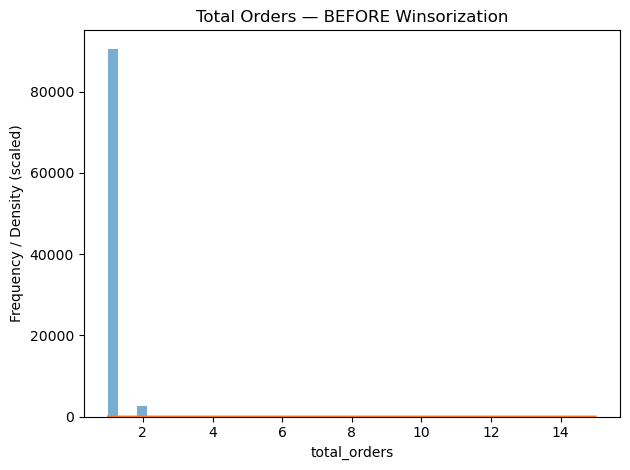

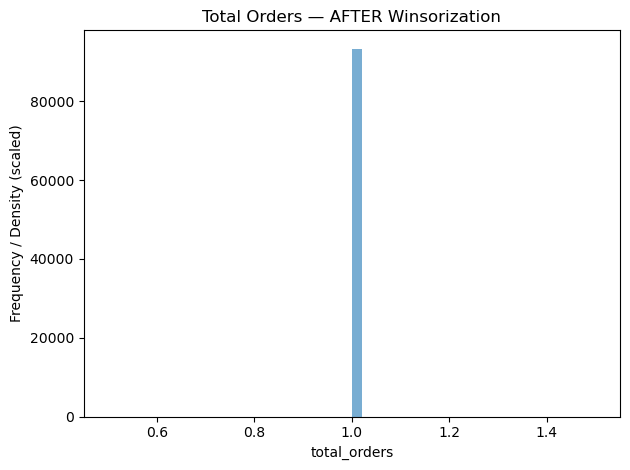

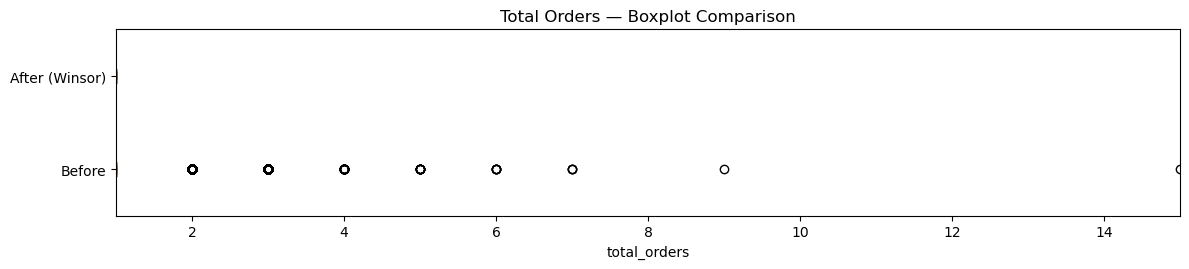

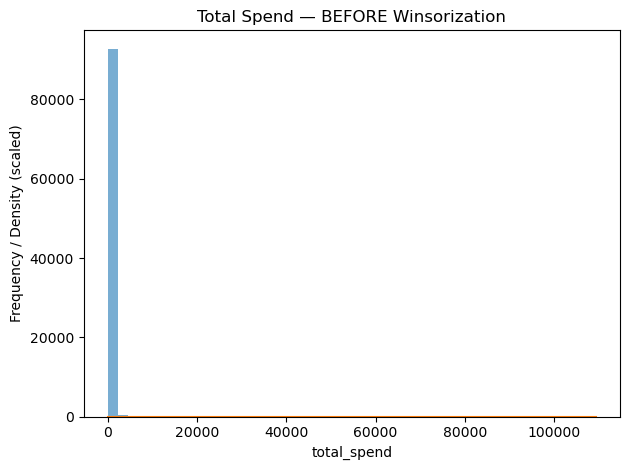

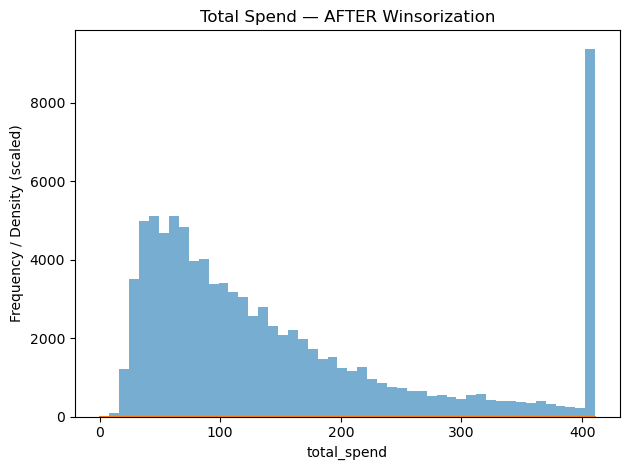

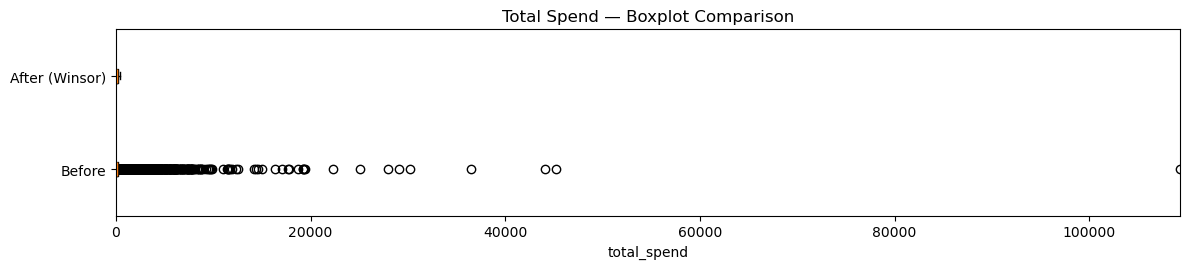

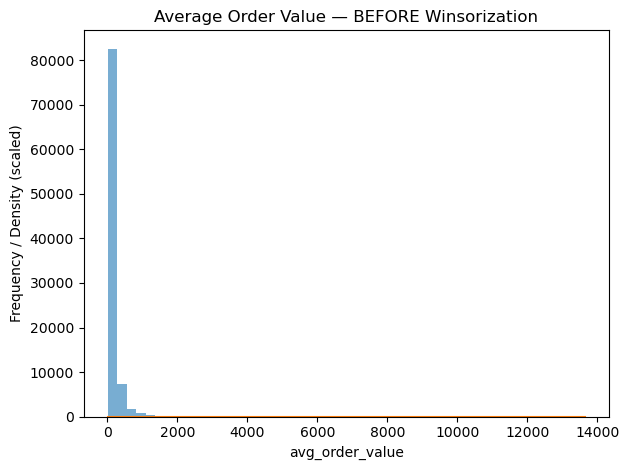

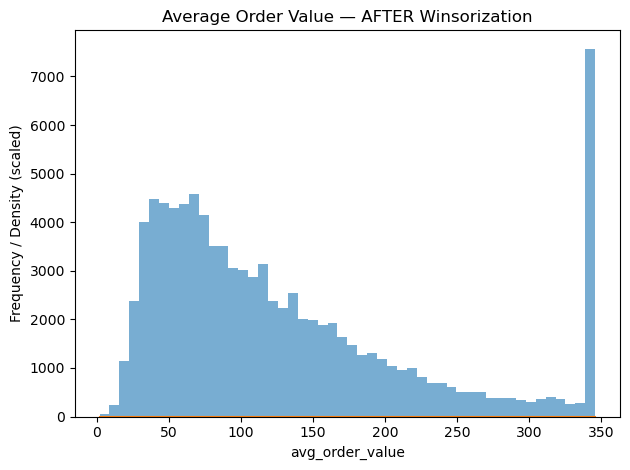

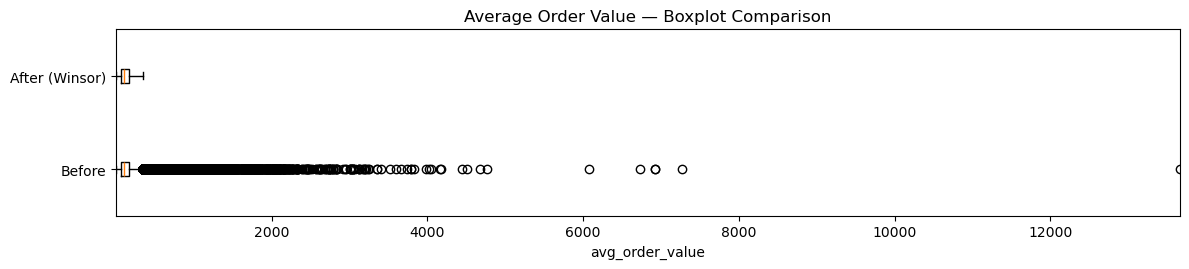

In [21]:
# === 6. BEFORE vs AFTER WINSORIZATION — separate histograms ===
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd

def plot_hist_density(data, title, xlabel, bins=50):
    """Histogram with smooth density curve (if possible)."""
    data = pd.to_numeric(data, errors="coerce").dropna()
    plt.hist(data, bins=bins, alpha=0.6)
    try:
        kde = gaussian_kde(data)
        xs = np.linspace(data.min(), data.max(), 400)
        plt.plot(xs, kde(xs))
    except Exception:
        pass
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency / Density (scaled)")
    plt.tight_layout()
    plt.show()

def compare_before_after_separate(before, after, title, xlabel, bins=50):
    b = pd.to_numeric(before, errors="coerce").dropna()
    a = pd.to_numeric(after, errors="coerce").dropna()
    if b.empty or a.empty:
        print(f"[WARN] Skipping {title}: empty data.")
        return

    xmin = min(b.min(), a.min())
    xmax = max(b.max(), a.max())

    # 1) Before histogram
    plot_hist_density(b, f"{title} — BEFORE Winsorization", xlabel, bins=bins)

    # 2) After histogram
    plot_hist_density(a, f"{title} — AFTER Winsorization", xlabel, bins=bins)

    # 3) Side-by-side horizontal boxplots
    fig, ax = plt.subplots(figsize=(12,2.8))
    ax.boxplot([b, a], vert=False, labels=["Before", "After (Winsor)"], showfliers=True)
    ax.set_xlim(xmin, xmax)
    ax.set_title(f"{title} — Boxplot Comparison")
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

# Run comparisons for the three winsorized metrics
pairs = [
    (col_total_orders,    "total_orders_winsor",    "Total Orders"),
    (col_total_spend,     "total_spend_winsor",     "Total Spend"),
    (col_avg_order_value, "avg_order_value_winsor", "Average Order Value")
]

for base_col, win_col, nice_name in pairs:
    if base_col and (win_col in df_final.columns):
        compare_before_after_separate(df_final[base_col], df_final[win_col], nice_name, base_col, bins=50)
    else:
        print(f"Skipping comparison for {nice_name}: base or winsorized column missing.")


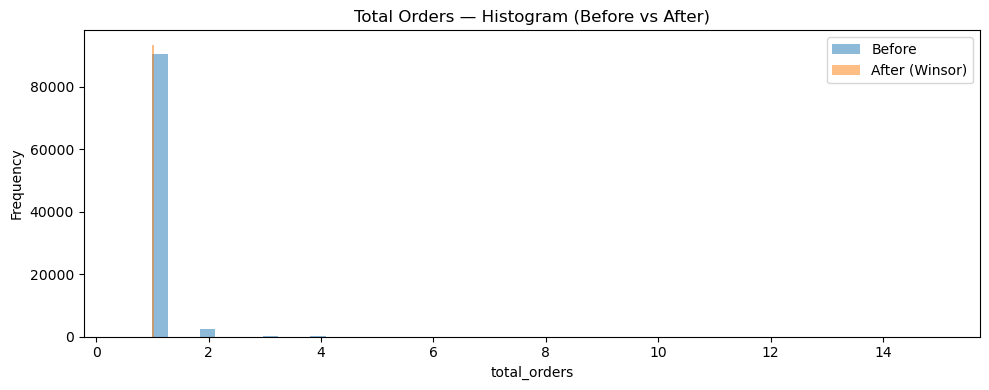

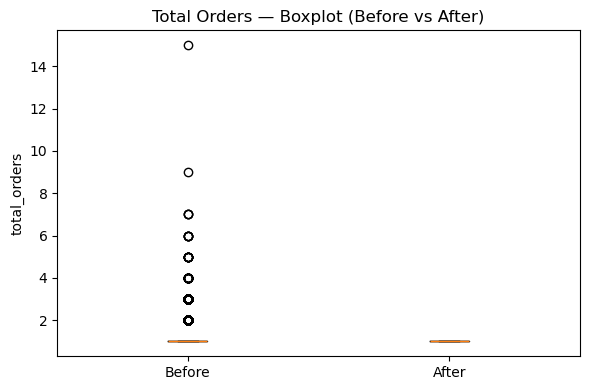

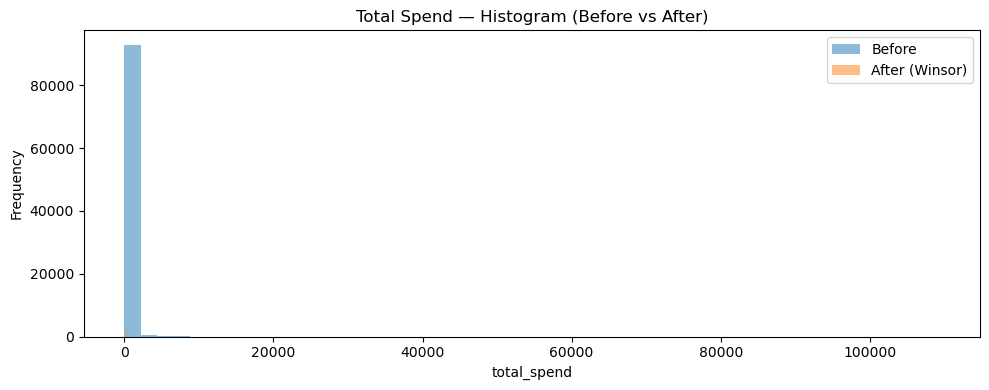

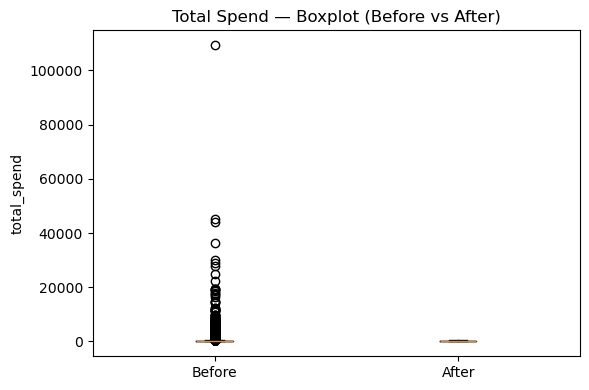

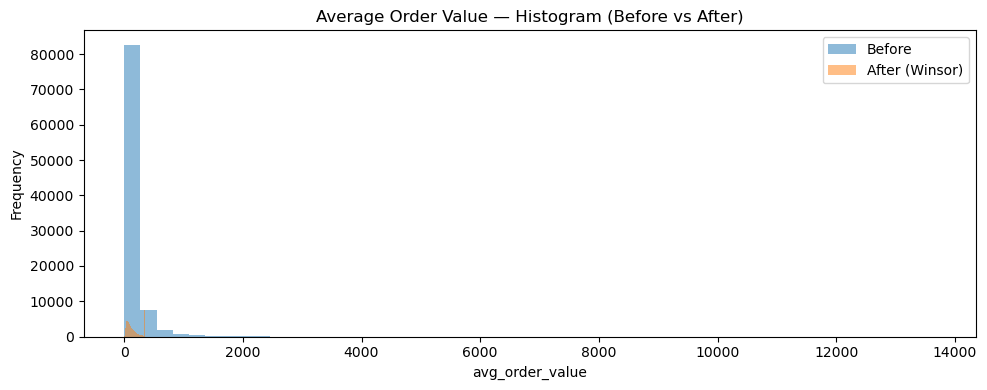

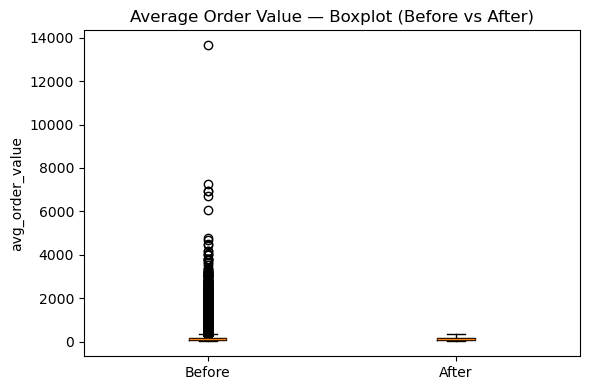

In [43]:
# === 6. COMPARE BEFORE vs AFTER ===
import matplotlib.pyplot as plt

def compare_before_after(before, after, title, xlabel, bins=50):
    b = pd.to_numeric(before, errors="coerce").dropna()
    a = pd.to_numeric(after, errors="coerce").dropna()
    if b.empty or a.empty:
        print(f"[WARN] Skipping {title}: empty data.")
        return

    # Histogram overlay
    plt.figure(figsize=(10,4))
    plt.hist(b, bins=bins, alpha=0.5, label="Before")
    plt.hist(a, bins=bins, alpha=0.5, label="After (Winsor)")
    plt.title(f"{title} — Histogram (Before vs After)")
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Side-by-side boxplots
    plt.figure(figsize=(6,4))
    plt.boxplot([b, a], labels=["Before", "After"])
    plt.title(f"{title} — Boxplot (Before vs After)")
    plt.ylabel(xlabel)
    plt.tight_layout()
    plt.show()

pairs = [
    (col_total_orders,    "total_orders_winsor",    "Total Orders"),
    (col_total_spend,     "total_spend_winsor",     "Total Spend"),
    (col_avg_order_value, "avg_order_value_winsor", "Average Order Value")
]

for base_col, win_col, nice_name in pairs:
    if base_col and win_col in df_wins.columns:
        compare_before_after(df_clean[base_col], df_wins[win_col], nice_name, base_col)
    else:
        print(f"Skipping comparison for {nice_name}: base or winsorized column missing.")



In [45]:
df_final.info()
df_final.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_unique_id        93358 non-null  object 
 1   total_orders              93358 non-null  int64  
 2   total_spend               93358 non-null  float64
 3   avg_order_value           93358 non-null  float64
 4   avg_payment_installments  93358 non-null  float64
 5   avg_review_score          93358 non-null  float64
 6   category_diversity        93358 non-null  int64  
 7   recency_days              93358 non-null  int64  
 8   most_common_category      93358 non-null  object 
 9   customer_city             93358 non-null  object 
 10  customer_state            93358 non-null  object 
 11  review_comment_message    93358 non-null  object 
 12  total_orders_winsor       93358 non-null  int64  
 13  total_spend_winsor        93358 non-null  float64
 14  avg_or

,total_orders,total_spend,avg_order_value,avg_payment_installments,avg_review_score,category_diversity,recency_days,total_orders_winsor,total_spend_winsor,avg_order_value_winsor
count,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000,93358.0,93358.000000,93358.000000
mean,1.033420,212.964557,157.786881,2.900284,4.158831,1.010979,236.941773,1.0,152.991574,131.665455
std,0.209097,646.223866,217.028441,2.677066,1.278231,0.204645,152.591453,0.0,117.390780,92.969417
min,1.000000,0.000000,1.856818,0.000000,1.000000,0.000000,0.000000,1.0,0.000000,1.856818
25%,1.000000,63.830000,60.730000,1.000000,4.000000,1.000000,113.000000,1.0,63.830000,60.730000
50%,1.000000,113.140000,103.590000,2.000000,5.000000,1.000000,218.000000,1.0,113.140000,103.590000
75%,1.000000,202.637500,174.730000,4.000000,5.000000,1.000000,345.000000,1.0,202.637500,174.730000
max,15.000000,109312.640000,13664.080000,24.000000,5.000000,5.000000,713.000000,1.0,410.848750,345.730000


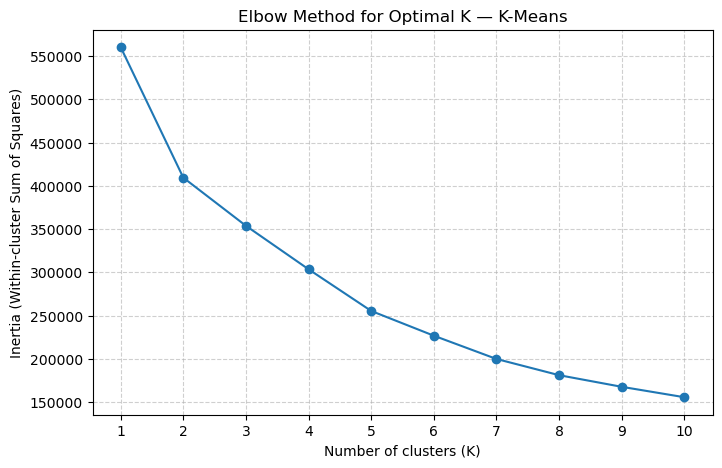

In [49]:
# === ELBOW METHOD for K-Means Clustering ===
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Select numeric features for clustering (using winsorized + other key numeric columns)
features_for_clustering = [
    'total_orders_winsor',
    'total_spend_winsor',
    'avg_order_value_winsor',
    metrics_map.get("avg_payment_installments"),
    metrics_map.get("avg_review_score"),
    metrics_map.get("category_diversity"),
    metrics_map.get("recency_days")
]

# Remove None values (if any column name wasn't found earlier)
features_for_clustering = [col for col in features_for_clustering if col is not None]

# 2. Prepare and standardize the dataset
X = df_final[features_for_clustering].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Run the elbow method
inertia_values = []
K_range = range(1, 11)  # K from 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# 4. Plot the elbow curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_values, marker='o', linestyle='-')
plt.xticks(K_range)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (Within-cluster Sum of Squares)")
plt.title("Elbow Method for Optimal K — K-Means")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [61]:
# === STEP 5: K-MEANS (K=5) ===
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Select features for clustering
features_for_clustering = [
    'total_orders_winsor',
    'total_spend_winsor',
    'avg_order_value_winsor',
    metrics_map.get("avg_payment_installments"),
    metrics_map.get("avg_review_score"),
    metrics_map.get("category_diversity"),
    metrics_map.get("recency_days")
]
features_for_clustering = [col for col in features_for_clustering if col is not None]

# 2. Prepare and standardize
X = df_final[features_for_clustering].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_final["cluster"] = kmeans.fit_predict(X_scaled)

# 4. Show cluster centroids (original scale)
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=features_for_clustering)
print("\nCluster centroids (original scale):")
display(centroids_df)

# 5. Show cluster sizes
print("\nCluster sizes:")
display(df_final["cluster"].value_counts().sort_index())

# 6. Show dataframe with cluster labels
print("\nFirst 20 rows of df_final with cluster labels:")
display(df_final.head(20))

# 7. Save to CSV for BERTopic modelling
df_final.to_csv("customer_segments_k5.csv", index=False)
print("\nDataframe saved as 'customer_segments_k5.csv' for BERTopic modelling.")


Cluster centroids (original scale):


,total_orders_winsor,total_spend_winsor,avg_order_value_winsor,avg_payment_installments,avg_review_score,category_diversity,recency_days
0,1.0,337.575582,282.055757,5.424750,4.206081,0.990868,236.520938
1,1.0,98.374348,91.558597,2.018795,4.689764,0.988811,125.222197
2,1.0,294.213022,156.617922,3.728075,3.890458,2.066173,204.075891
3,1.0,127.197902,107.397639,2.538870,1.672566,0.981470,232.837061
4,1.0,99.136416,90.944628,2.450146,4.635347,0.980772,398.190666



Cluster sizes:


cluster
0    17959
1    35337
2     2161
3    12512
4    25389
Name: count, dtype: int64


First 20 rows of df_final with cluster labels:


,customer_unique_id,total_orders,total_spend,avg_order_value,avg_payment_installments,avg_review_score,category_diversity,recency_days,most_common_category,customer_city,customer_state,review_comment_message,total_orders_winsor,total_spend_winsor,avg_order_value_winsor,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,8.0,5.0,1,111,bed_bath_table,cajamar,SP,"Adorei a cortina, ficou linda na minha sala, e...",1,141.90000,141.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1.0,4.0,1,114,health_beauty,osasco,SP,Muito bom,1,27.19000,27.19,1
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,8.0,3.0,1,536,stationery,sao jose,SC,Muito bom,1,86.22000,86.22,4
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,4.0,1,320,telephony,belem,PA,Bom vendedor,1,43.62000,43.62,4
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,6.0,5.0,1,287,telephony,sorocaba,SP,Muito bom,1,196.89000,196.89,0
5,0004bd2a26a76fe21f786e4fbd80607f,1,166.98,166.98,8.0,4.0,1,145,garden_tools,sao paulo,SP,Muito bom,1,166.98000,166.98,0
6,00050ab1314c0e55a6ca13cf7181fecf,1,35.38,35.38,1.0,4.0,1,131,telephony,campinas,SP,Muito bom,1,35.38000,35.38,1
7,00053a61a98854899e70ed204dd4bafe,1,838.36,419.18,3.0,1.0,1,182,sports_leisure,curitiba,PR,Olá! Comprei dois potes de whey e chegou apena...,1,410.84875,345.73,0
8,0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,3.0,4.0,1,542,fashion_bags_accessories,teresopolis,RJ,Muito bom,1,150.12000,150.12,4
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,129.76,129.76,4.0,1.0,1,169,sports_leisure,sao luis,MA,Até o presente momento não recebi o produto e ...,1,129.76000,129.76,3



Dataframe saved as 'customer_segments_k5.csv' for BERTopic modelling.


In [59]:
# === ANOVA + Tukey's HSD for K-Means Clusters ===
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Choose numeric variables to test
numeric_features = [
    'total_orders_winsor',
    'total_spend_winsor',
    'avg_order_value_winsor',
    metrics_map.get("avg_payment_installments"),
    metrics_map.get("avg_review_score"),
    metrics_map.get("category_diversity"),
    metrics_map.get("recency_days")
]
numeric_features = [col for col in numeric_features if col is not None]

anova_results = []

# 2. Run ANOVA for each numeric feature
for feature in numeric_features:
    groups = [df_final[df_final['cluster'] == c][feature] for c in sorted(df_final['cluster'].unique())]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({
        'Feature': feature,
        'F-statistic': f_stat,
        'p-value': p_val
    })

anova_df = pd.DataFrame(anova_results)
anova_df['Significant (p<0.05)'] = anova_df['p-value'] < 0.05

print("\nANOVA Results:")
display(anova_df)

# 3. Tukey's HSD for significant features
for feature in anova_df.loc[anova_df['Significant (p<0.05)'], 'Feature']:
    print(f"\n--- Tukey's HSD for {feature} ---")
    tukey = pairwise_tukeyhsd(
        endog=df_final[feature],           # the data
        groups=df_final['cluster'],        # cluster labels
        alpha=0.05                         # 95% confidence
    )
    print(tukey.summary())



ANOVA Results:


C:\Users\User\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


,Feature,F-statistic,p-value,Significant (p<0.05)
0,total_orders_winsor,NaN,NaN,False
1,total_spend_winsor,44248.388341,0.0,True
2,avg_order_value_winsor,40894.723570,0.0,True
3,avg_payment_installments,6757.710517,0.0,True
4,avg_review_score,36772.535435,0.0,True
5,category_diversity,39810.716206,0.0,True
6,recency_days,24044.056789,0.0,True



--- Tukey's HSD for total_spend_winsor ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
     0      1 -239.1258    0.0 -240.8503 -237.4014   True
     0      2  -43.3559    0.0  -47.6404  -39.0713   True
     0      3  -210.417    0.0 -212.6083 -208.2257   True
     0      4 -238.5028    0.0 -240.3376 -236.6681   True
     1      2    195.77    0.0  191.6001  199.9399   True
     1      3   28.7088    0.0   26.7512   30.6664   True
     1      4     0.623 0.8078   -0.9252    2.1711  False
     2      3 -167.0611    0.0 -171.4448 -162.6775   True
     2      4  -195.147    0.0 -199.3637 -190.9303   True
     3      4  -28.0858    0.0  -30.1413  -26.0304   True
---------------------------------------------------------

--- Tukey's HSD for avg_order_value_winsor ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower

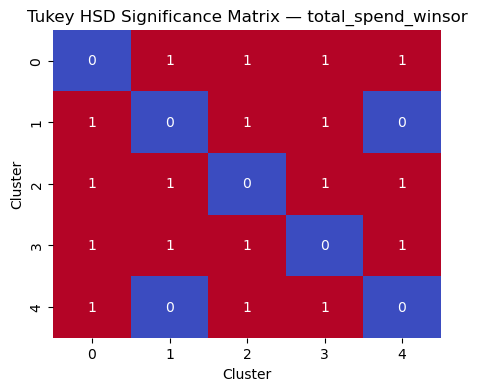

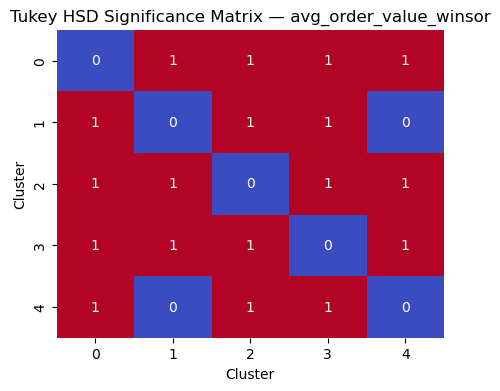

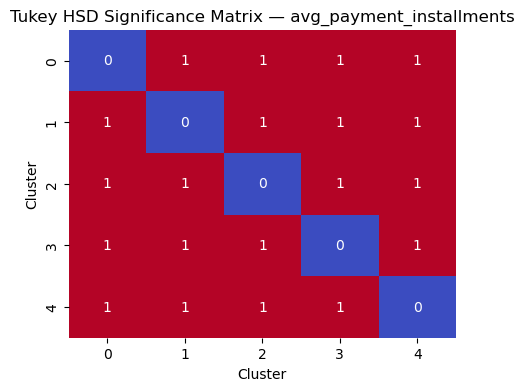

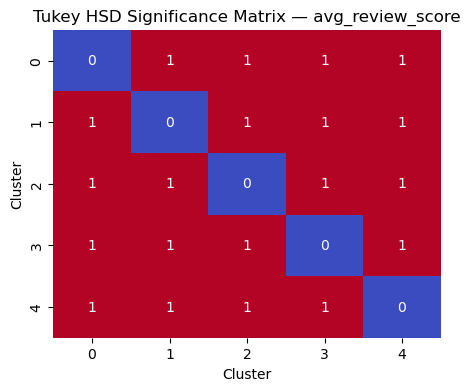

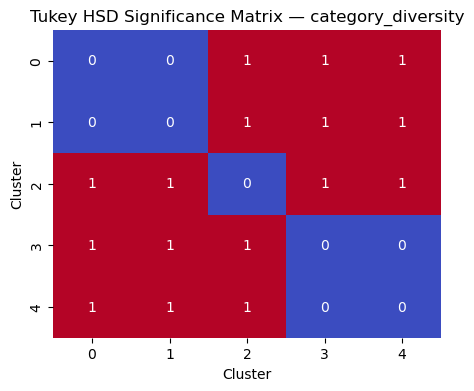

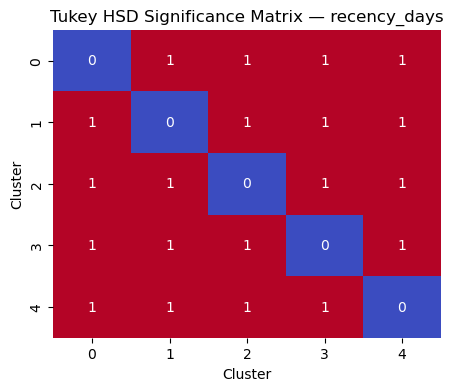

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Function to create Tukey significance matrix
def tukey_matrix(data, variable, cluster_col='cluster'):
    tukey = pairwise_tukeyhsd(endog=data[variable], groups=data[cluster_col], alpha=0.05)
    results = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    
    # Initialize matrix
    clusters = sorted(data[cluster_col].unique())
    mat = pd.DataFrame(0, index=clusters, columns=clusters)
    
    # Fill matrix: 1 if significant, else 0
    for _, row in results.iterrows():
        c1, c2 = int(row['group1']), int(row['group2'])
        sig = int(row['reject'])  # True = 1, False = 0
        mat.loc[c1, c2] = sig
        mat.loc[c2, c1] = sig
    
    return mat

# Variables to check
variables = [
    'total_spend_winsor',
    'avg_order_value_winsor',
    'avg_payment_installments',
    'avg_review_score',
    'category_diversity',
    'recency_days'
]

# Plot heatmaps
for var in variables:
    mat = tukey_matrix(df_final, var)
    plt.figure(figsize=(5, 4))
    sns.heatmap(mat, annot=True, cmap='coolwarm', cbar=False, fmt='d')
    plt.title(f"Tukey HSD Significance Matrix — {var}")
    plt.xlabel("Cluster")
    plt.ylabel("Cluster")
    plt.show()


In [67]:
# Create a dictionary to store DataFrames for each cluster
cluster_dfs = {}

# Loop through unique clusters and save their data into separate DataFrames
for clust in df_final["cluster"].unique():
    cluster_dfs[clust] = df_final[df_final["cluster"] == clust].copy()
    # Save each cluster as a CSV
    cluster_dfs[clust].to_csv(f"C:/Users/User/OneDrive - University of Exeter/Desktop/Business Project/cluster_{clust}.csv", index=False)

# Provide the file paths for download
cluster_files = {clust: f"C:/Users/User/OneDrive - University of Exeter/Desktop/Business Project/cluster_{clust}.csv" for clust in cluster_dfs.keys()}
cluster_files


{1: 'C:/Users/User/OneDrive - University of Exeter/Desktop/Business Project/cluster_1.csv',
 4: 'C:/Users/User/OneDrive - University of Exeter/Desktop/Business Project/cluster_4.csv',
 0: 'C:/Users/User/OneDrive - University of Exeter/Desktop/Business Project/cluster_0.csv',
 3: 'C:/Users/User/OneDrive - University of Exeter/Desktop/Business Project/cluster_3.csv',
 2: 'C:/Users/User/OneDrive - University of Exeter/Desktop/Business Project/cluster_2.csv'}